In [1]:
import duckdb
print(duckdb.__version__)

1.5.0


In [2]:
duckdb.sql("SELECT 1").show()

┌───────┐
│   1   │
│ int32 │
├───────┤
│     1 │
└───────┘



In [3]:
con = duckdb.connect()

# 테이블 생성
con.execute("""
CREATE OR REPLACE TABLE game_log AS 
SELECT 
    event_id,
    event_name,
    event_timestamp,
    user_id,
    user_session_id,
    user_session_issued_at,
    user_session_count,
    country_code,
    processing_time
FROM read_csv_auto('D:/game_data/user_log.csv')
""")


In [4]:
# 확인
df = con.sql("""
SELECT * 
FROM game_log 
LIMIT 3
""").df()

df

,event_id,event_name,event_timestamp,user_id,user_session_id,user_session_issued_at,user_session_count,country_code,processing_time
0,4a2cf430-d178-45fd-8028-05ac393814a1,appBackground,2025-03-11 14:10:27,92aabe08-e23e-4f74-96ff-b77b7adaadfb,0513d7cf-c5f1-4f3d-8048-5d440f32690b,2025-02-11 15:04:20,1,CA,2025-03-11 14:04:30.899
1,d97bcb86-5cd2-4ef2-a528-e86023bc5087,appBackground,2025-03-11 14:10:34,92aabe08-e23e-4f74-96ff-b77b7adaadfb,0513d7cf-c5f1-4f3d-8048-5d440f32690b,2025-02-11 15:04:20,1,CA,2025-03-11 14:04:30.899
2,45936e91-a76a-4e75-b2f7-d31af6241dc3,appFocus,2025-03-11 14:10:46,92aabe08-e23e-4f74-96ff-b77b7adaadfb,0513d7cf-c5f1-4f3d-8048-5d440f32690b,2025-02-11 15:04:20,1,CA,2025-03-11 14:04:30.899


In [5]:
con.sql("""
        SELECT event_name
             , COUNT(event_id) AS cnt
        FROM game_log
        GROUP BY event_name
        ORDER BY cnt DESC
        LIMIT 30
        """ ).df()

,event_name,cnt
0,tokenCashout,381332
1,lostCustomer,270877
2,interstitialLifecycle,204732
3,rvLifecycle,173324
4,appBackground,166042
5,transferMoney,160028
6,appFocus,153105
7,deviceBroken,135162
8,deviceRepair,123974
9,achievementUpdated,114105


In [6]:
#세션별 자주 발생하는 이벤트(수)
con.sql("""
        SELECT user_session_id
             , event_name
             , COUNT(event_id) AS cnt
        FROM game_log
        GROUP BY user_session_id, event_name
        ORDER BY cnt DESC
        LIMIT 20
        """ ).df()

,user_session_id,event_name,cnt
0,None,achievementUpdated,114105
1,None,currencyGranted,75021
2,None,currencySpent,63619
3,None,itemsGranted,9711
4,None,achievementClaimed,5700
5,None,_identityCreate,2051
6,9361b509-0029-4010-9295-85f02e03ba23,rvLifecycle,908
7,f8993f0a-a2a2-44f6-9915-048fcfa2cc6a,lostCustomer,903
8,4c1cd10a-35fb-4e35-976a-4191d597a8e6,lostCustomer,873
9,bf903ca7-03f5-42a1-aff0-c0d2fde2c452,rvLifecycle,852


In [7]:
#Cohort 날짜별 신규 유저 유입

con.sql("""
        SELECT DATE(event_timestamp) AS first_dt
             , COUNT(DISTINCT user_id) AS user_cnt
        FROM game_log
        WHERE event_name = 'firstOpen'
        GROUP BY DATE(event_timestamp)
        ORDER BY DATE(event_timestamp)
""").df()

 

,first_dt,user_cnt
0,2025-03-01,485
1,2025-03-02,288
2,2025-03-03,89
3,2025-03-04,456
4,2025-03-05,636
5,2025-03-11,1


분석에는 2025-02-28부터 2025-03-05까지의 로그를 활용</br>
리텐션 분석은 다음날 접속 여부를 확인할 수 있는 2025-03-04 이전 가입 유저를 기준으로 수행했으며,</br>
구매 및 초기 행동 패턴 분석은 가입 당일 로그만으로 확인 가능하므로 2025-03-05 가입 유저까지 포함하였다.

In [8]:
#테이블 확장

con.execute("""
CREATE OR REPLACE TABLE game_log AS
SELECT
    event_id,
    event_name,
    event_timestamp,
    user_id,
    user_session_id,
    user_session_issued_at,
    user_session_count,
    country_code,
    processing_time
FROM read_csv_auto('D:/game_data/user_log.csv')

UNION ALL

SELECT
    event_id,
    event_name,
    event_timestamp,
    user_id,
    user_session_id,
    user_session_issued_at,
    user_session_count,
    country_code,
    processing_time
FROM read_parquet('D:/player_data/part5.parquet')
            
UNION ALL
            
SELECT
    event_id,
    event_name,
    event_timestamp,
    user_id,
    user_session_id,
    user_session_issued_at,
    user_session_count,
    country_code,
    processing_time
FROM read_parquet('D:/player_data/part6.parquet')                       
""")

In [9]:
con.sql("""
        SELECT COUNT(*)
        FROM game_log""")

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│      5030780 │
└──────────────┘

In [10]:
#날짜별 게임 접속 유저
con.sql("""
       SELECT DATE(event_timestamp) AS dt
     , COUNT(DISTINCT user_id) AS user_cnt
       FROM game_log
       WHERE DATE(event_timestamp) <= '2025-03-06'
         AND event_name = 'gameOpened'
       GROUP BY DATE(event_timestamp)
       ORDER BY dt;
        """).df()

,dt,user_cnt
0,2025-02-28,325
1,2025-03-01,2778
2,2025-03-02,2749
3,2025-03-03,1092
4,2025-03-04,2686
5,2025-03-05,2532
6,2025-03-06,1


In [11]:
#신규 유저('firstOpen') 클래식 리텐션(DAY0~DAY5)_데이터 제한

df = con.sql("""
        WITH first AS (
        SELECT user_id
             , MIN(DATE(event_timestamp)) AS first_visit_dt
        FROM game_log
        WHERE event_name = 'firstOpen'
          AND DATE(event_timestamp) <= '2025-03-04'
        GROUP BY user_id
        )
        , visit AS (
        SELECT DISTINCT user_id
             , DATE(event_timestamp) AS visit_dt
        FROM game_log
        WHERE event_name = 'gameOpened'
          AND DATE(event_timestamp) <= '2025-03-05'
        )
   
        SELECT first_visit_dt
             , COUNT(DISTINCT CASE WHEN visit_dt = first_visit_dt THEN f.user_id END) AS day0
             , COUNT(DISTINCT CASE WHEN visit_dt = DATE_ADD(first_visit_dt, INTERVAL 1 DAY) THEN f.user_id END) AS day1
             , COUNT(DISTINCT CASE WHEN visit_dt = DATE_ADD(first_visit_dt, INTERVAL 2 DAY) THEN f.user_id END) AS day2
             , COUNT(DISTINCT CASE WHEN visit_dt = DATE_ADD(first_visit_dt, INTERVAL 3 DAY) THEN f.user_id END) AS day3
             , COUNT(DISTINCT CASE WHEN visit_dt = DATE_ADD(first_visit_dt, INTERVAL 4 DAY) THEN f.user_id END) AS day4
             , COUNT(DISTINCT CASE WHEN visit_dt = DATE_ADD(first_visit_dt, INTERVAL 5 DAY) THEN f.user_id END) AS day5
        FROM first AS f 
        LEFT JOIN visit AS v ON f.user_id = v.user_id
        GROUP BY first_visit_dt
        ORDER BY first_visit_dt
        """).df() 

df


,first_visit_dt,day0,day1,day2,day3,day4,day5
0,2025-02-28,82,27,17,2,6,6
1,2025-03-01,867,208,41,72,61,0
2,2025-03-02,732,60,90,70,0,0
3,2025-03-03,328,103,54,0,0,0
4,2025-03-04,821,207,0,0,0,0


In [12]:
# df.to_excel('D:/game_data/retention.xlsx', index=False)

In [13]:
con.sql("""
        SELECT *
        FROM game_log
        LIMIT 3
        """).df()


,event_id,event_name,event_timestamp,user_id,user_session_id,user_session_issued_at,user_session_count,country_code,processing_time
0,4a2cf430-d178-45fd-8028-05ac393814a1,appBackground,2025-03-11 14:10:27,92aabe08-e23e-4f74-96ff-b77b7adaadfb,0513d7cf-c5f1-4f3d-8048-5d440f32690b,2025-02-11 15:04:20,1,CA,2025-03-11 14:04:30.899
1,d97bcb86-5cd2-4ef2-a528-e86023bc5087,appBackground,2025-03-11 14:10:34,92aabe08-e23e-4f74-96ff-b77b7adaadfb,0513d7cf-c5f1-4f3d-8048-5d440f32690b,2025-02-11 15:04:20,1,CA,2025-03-11 14:04:30.899
2,45936e91-a76a-4e75-b2f7-d31af6241dc3,appFocus,2025-03-11 14:10:46,92aabe08-e23e-4f74-96ff-b77b7adaadfb,0513d7cf-c5f1-4f3d-8048-5d440f32690b,2025-02-11 15:04:20,1,CA,2025-03-11 14:04:30.899


가설 1. 첫날 광고 시청 횟수가 일정 수준을 초과할 경우 리텐션이 감소하는가?</br>
가설 2. 첫날 성장 관련 이벤트 발생 빈도가 높은 유저일 수록 리텐션이 높은가?</br>
가설 3. 첫날 구매 경험이 있는 유저는 리텐션이 높은가? -> 첫날 구매 경험이 있는 유저의 행동 패턴은?

In [14]:
#가설1 -> 유저마다 광고 몇 번 봤고, 다음날 다시 왔냐(1,0으로 표시)
df = con.sql("""
        WITH first_open AS(
        SELECT user_id
             , MIN(DATE(event_timestamp)) AS first_dt
        FROM game_log
        WHERE event_name = 'firstOpen'
          AND DATE(event_timestamp) <= '2025-03-04'
        GROUP BY user_id
        ), ads_cnt AS(
        SELECT f.user_id
             , f.first_dt
             , COUNT(g.event_id) AS ad_cnt
        FROM first_open f
        LEFT JOIN game_log g ON f.user_id = g.user_id
                             AND g.event_name = 'adsStart'
                             AND DATE(g.event_timestamp) = f.first_dt
        GROUP BY f.first_dt, f.user_id 
        )
        SELECT a.user_id
             , a.first_dt
             , a.ad_cnt
             , CASE 
                WHEN COUNT(g.user_id) > 0 THEN 1
                ELSE 0
               END AS retained_01
        FROM ads_cnt a
        LEFT JOIN game_log g ON a.user_id = g.user_id
                             AND DATE(g.event_timestamp) = DATE_ADD(a.first_dt, INTERVAL 1 DAY) 
                             AND g.event_name = 'gameOpened'
        GROUP BY a.user_id, a.first_dt, a.ad_cnt
        ORDER BY a.first_dt, a.user_id
        """).df()

df
#리텐션은 gameOpened 이벤트를 기준으로 정의

,user_id,first_dt,ad_cnt,retained_01
0,01ec3c47-a8f7-4fbf-b4d2-0b3e82cf65fb,2025-02-28,2,0
1,0385943d-247c-41aa-b90c-3754e5156fc8,2025-02-28,1,0
2,043ac359-de40-4832-b60f-99d3bb72d654,2025-02-28,12,0
3,114f730a-4b3f-42b9-87be-100026fdffe7,2025-02-28,5,1
4,1351142f-b899-4b7a-b957-3ad5c9a92f0c,2025-02-28,3,0
...,...,...,...,...
2850,fea764ca-6bd3-431a-b0bb-a13f7881babb,2025-03-04,3,0
2851,feb5f62d-6d39-4944-a483-76142fc4535c,2025-03-04,5,0
2852,fee0bf53-e37f-4037-8d86-6708d807cf9c,2025-03-04,21,0
2853,fef3d7c0-8a7e-4afc-92bb-2010b7b62ece,2025-03-04,6,0


In [15]:
df.describe()

,first_dt,ad_cnt,retained_01
count,2855,2855.000000,2855.000000
mean,2025-03-02 07:41:00.105078,9.848687,0.211909
min,2025-02-28 00:00:00,0.000000,0.000000
25%,2025-03-01 00:00:00,1.000000,0.000000
50%,2025-03-02 00:00:00,4.000000,0.000000
75%,2025-03-04 00:00:00,11.000000,0.000000
max,2025-03-04 00:00:00,227.000000,1.000000
std,NaN,17.217706,0.408732


<Axes: >

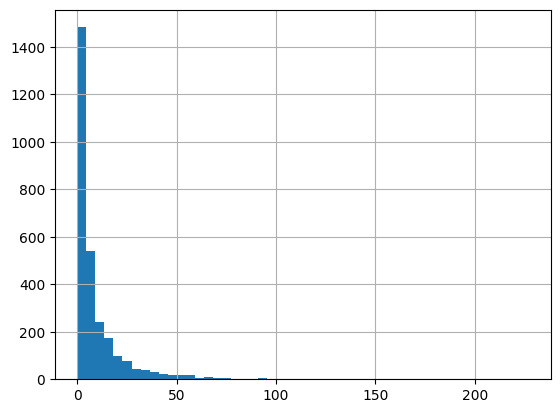

In [16]:
df['ad_cnt'].hist(bins=50)
#광고 시청 횟수 분포는 일부 극단값(최대 189회)의 영향을 받아 평균이 왜곡될 수 있어,
#상위 구간을 제한한 분석과 전체 분포를 함께 비교하였다.

In [17]:
#광고 시청 횟수 분포는 상위 일부 유저에서 극단적으로 높은 값을 보였으며,
#IQR 기준(Q3 + 1.5×IQR)을 통해 이상치를 정의하고 일반 유저 패턴과 분리하여 분석하였다.
#메인 분석 ad_cnt <= 26 일반 유저 패턴
#서브 인사이트 ad_cnt > 26 과도한 광고 노출 유저 그룹 존재

df1 = df[df['ad_cnt'] <= 26].copy()
print(df1.shape) #메인

df2 = df[df['ad_cnt'] > 26].copy()
print(df2.shape) #서브

(2596, 4)
(259, 4)


극단적 행동 유저가 결과를 왜곡할 수 있어</br>
일반적인 유저 행동 패턴 중심으로 분석하기 위해 IQR 기반으로 상한값 설정

[이상치 처리 기준 정의]
ad_cnt 분포 확인,
IQR 기준 상한값 26 도출,
상위 극단값 유저 존재 확인</br>
→ 분석 왜곡 방지를 위해 필터링 적용

In [18]:
con.register('ad_user', df1)

In [19]:
con.register('ex_ad_user', df2)

In [20]:
#분포 기반 ad_cnt 구간 설정
ad_retained = con.sql("""
        WITH level AS (
        SELECT *
             , CASE
                WHEN ad_cnt == 0 THEN 'NO_Ads'             
                WHEN ad_cnt <= 1 THEN 'LOW'
                WHEN ad_cnt <= 4 THEN 'MID-LOW'
                WHEN ad_cnt <= 11 THEN 'MID-HIGH'
                ELSE 'HIGH'
               END AS ad_level   
        FROM ad_user
        )
     SELECT *
          , ROUND(user_cnt * 100 / SUM(user_cnt) OVER (), 2) ratio_pct
     FROM (
        SELECT ad_level
             , ROUND(AVG(retained_01) * 100, 2) AS avg_r
             , COUNT(*) user_cnt
        FROM level
        GROUP BY ad_level) AS retained
     ORDER BY avg_r DESC
        """).df()

ad_retained


,ad_level,avg_r,user_cnt,ratio_pct
0,HIGH,31.70,429,16.53
1,MID-HIGH,22.63,685,26.39
2,MID-LOW,16.48,637,24.54
3,LOW,16.08,311,11.98
4,NO_Ads,12.55,534,20.57


In [21]:
df2['ad_cnt'].describe()

count    259.000000
mean      51.517375
std       31.159671
min       27.000000
25%       33.000000
50%       41.000000
75%       57.000000
max      227.000000
Name: ad_cnt, dtype: float64

<Axes: >

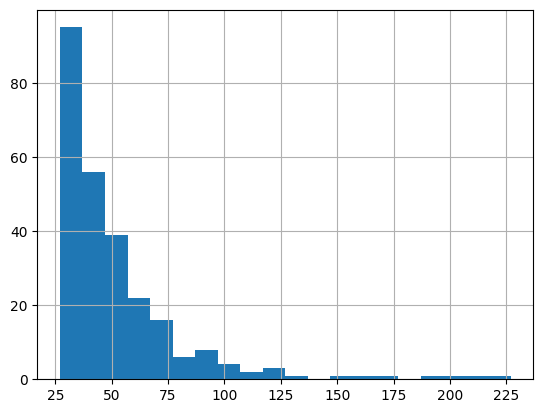

In [22]:
df2['ad_cnt'].hist(bins=20)

In [23]:
#광고 상한치 이상 노출 유저 리텐션율
#리텐션율 높게 나타나지만, 유저수는 극히 줄어듬

con.sql("""
        WITH level AS (
        SELECT *
             , CASE
                WHEN ad_cnt <= 33 THEN 'LOW'
                WHEN ad_cnt <= 41 THEN 'MID-LOW'
                WHEN ad_cnt <= 57 THEN 'MID-HIGH'
                WHEN ad_cnt <= 100 THEN 'HIGH'
                ELSE 'EXTREME'
               END ex_ad_lev 
        FROM ex_ad_user
        )
        SELECT *
             , ROUND(user_cnt * 100 / SUM(user_cnt) OVER (), 2) ratio_pct
       FROM (  
        SELECT ex_ad_lev
             , ROUND(AVG(retained_01) * 100, 2) AS avg_r 
             , COUNT(*) AS user_cnt
        FROM level
        GROUP BY ex_ad_lev) AS retained
        ORDER BY user_cnt DESC
        """).df()

,ex_ad_lev,avg_r,user_cnt,ratio_pct
0,LOW,29.41,68,26.25
1,MID-LOW,35.38,65,25.10
2,MID-HIGH,33.87,62,23.94
3,HIGH,42.86,49,18.92
4,EXTREME,46.67,15,5.79


초기 분석에서 광고 노출 수준과 리텐션 간 양의 관계가 관찰되었으나,</br>
해당 관계가 광고 자체 효과인지 사용자 몰입도에 따른 결과인지 구분하기 위해</br>
추가적으로 행동 기반 지표(event_proxy, event_dvs)를 도입하여 분석을 확장하였다.

In [24]:
#성장/보상 이벤트로 분리
con.sql("""
        SELECT event_name
             , COUNT(*) cnt
        FROM game_log
        GROUP BY event_name
        HAVING event_name IN ('achievementUpdated', 'offerClaim', 'deviceUpgrade', 'boosterClaimed', 'gamerRoadClaimed', 
                              'achievementClaimed', 'zoneUnlocked', 'playerAbilityClaimed', 'deviceUnlocked') 
        ORDER BY cnt DESC
        """).df()

,event_name,cnt
0,achievementUpdated,208680
1,deviceUpgrade,135750
2,deviceUnlocked,62821
3,offerClaim,26918
4,boosterClaimed,19373
5,playerAbilityClaimed,11197
6,achievementClaimed,10322
7,zoneUnlocked,10171
8,gamerRoadClaimed,4453


In [25]:
#활동량proxy(성장/보상 관련 이벤트로 필터링, 활동 지표 재정의) 
#모든 이벤트 수proxy는 실제 몰입도 반영하지 못할 가능성 존재, 지표 재정의 후 이벤트 수 및 다양성 반영
event = con.sql("""
        SELECT au.user_id 
             , au.first_dt 
             , au.ad_cnt
             , au.retained_01
             , COUNT(g.event_id) AS event_proxy
             , COUNT(DISTINCT g.event_name) AS event_dvs
        FROM ad_user au
        LEFT JOIN game_log g ON au.user_id = g.user_id
                             AND au.first_dt = DATE(g.event_timestamp)
                             AND g.event_name IN ('achievementUpdated', 'offerClaim', 'deviceUpgrade', 'boosterClaimed', 'gamerRoadClaimed', 
                                                  'achievementClaimed', 'zoneUnlocked', 'playerAbilityClaimed', 'deviceUnlocked') 
        GROUP BY au.user_id, au.first_dt, au.ad_cnt, au.retained_01
        ORDER BY au.first_dt, au.user_id
        """).df()

event

,user_id,first_dt,ad_cnt,retained_01,event_proxy,event_dvs
0,01ec3c47-a8f7-4fbf-b4d2-0b3e82cf65fb,2025-02-28,2,0,15,5
1,0385943d-247c-41aa-b90c-3754e5156fc8,2025-02-28,1,0,15,5
2,043ac359-de40-4832-b60f-99d3bb72d654,2025-02-28,12,0,83,9
3,114f730a-4b3f-42b9-87be-100026fdffe7,2025-02-28,5,1,35,6
4,1351142f-b899-4b7a-b957-3ad5c9a92f0c,2025-02-28,3,0,11,6
...,...,...,...,...,...,...
2591,fea764ca-6bd3-431a-b0bb-a13f7881babb,2025-03-04,3,0,20,6
2592,feb5f62d-6d39-4944-a483-76142fc4535c,2025-03-04,5,0,26,7
2593,fee0bf53-e37f-4037-8d86-6708d807cf9c,2025-03-04,21,0,82,7
2594,fef3d7c0-8a7e-4afc-92bb-2010b7b62ece,2025-03-04,6,0,44,7


In [26]:
event['event_proxy'].describe()
#109초과 이상치로 간주

count    2596.000000
mean       33.347072
std        33.298916
min         0.000000
25%         9.000000
50%        22.000000
75%        49.000000
max       290.000000
Name: event_proxy, dtype: float64

<Axes: >

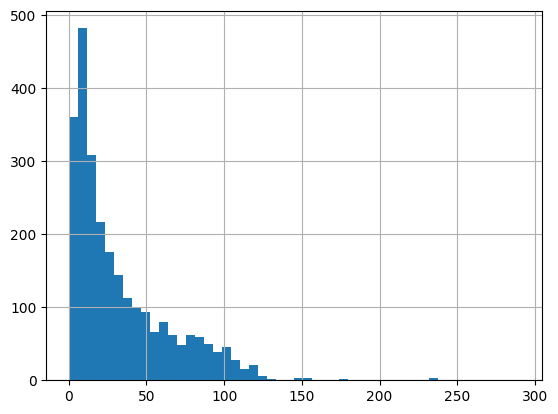

In [27]:
event['event_proxy'].hist(bins=50)

In [28]:
event1 = event[event['event_proxy'] <= 109].copy()
print(event1.shape)

event2 = event[event['event_proxy'] > 109].copy()
print(event2.shape)

(2530, 6)
(66, 6)


In [29]:
con.register('event_user', event1)

최종 표본</br>
ad_cnt <= 26 </br>
AND event_proxy <= 109

In [30]:
cross = con.sql("""
        WITH segment AS (
        SELECT *
             , CASE
                WHEN ad_cnt = 0 THEN 'NO_Ads'             
                WHEN ad_cnt <= 1 THEN 'LOW'
                WHEN ad_cnt <= 4 THEN 'MID-LOW'
                WHEN ad_cnt <= 11 THEN 'MID-HIGH'
                ELSE 'HIGH'
               END AS ad_cnt_lev    
             , CASE
                WHEN event_proxy = 0 THEN 'NO_Acts'
                WHEN event_proxy <= 9 THEN 'LOW'
                WHEN event_proxy <= 22 THEN 'MID-LOW'
                WHEN event_proxy <= 49 THEN 'MID-HIGH'
                ELSE 'HIGH'
               END event_proxy_lev
        FROM event_user
        )
      , event_seg AS ( 
        SELECT event_proxy_lev
             , ROUND(AVG(retained_01) * 100, 2) AS event_avg_r
        FROM segment
        GROUP BY event_proxy_lev
        ORDER BY event_avg_r DESC
        )
      , ad_seg AS (  
        SELECT ad_cnt_lev 
             , ROUND(AVG(retained_01) * 100, 2) AS ad_avg_r
        FROM segment
        GROUP BY ad_cnt_lev
        ORDER BY ad_avg_r DESC
        )

     SELECT ad_cnt_lev
          , event_proxy_lev
          , ROUND(AVG(retained_01) * 100, 2) avg_r
          , COUNT(*) user_cnt
     FROM segment 
     GROUP BY ad_cnt_lev, event_proxy_lev
     ORDER BY user_cnt DESC
    """).df()

cross

,ad_cnt_lev,event_proxy_lev,avg_r,user_cnt
0,NO_Ads,LOW,11.23,383
1,MID-HIGH,MID-HIGH,22.46,374
2,HIGH,HIGH,30.38,339
3,MID-LOW,MID-LOW,15.48,336
4,MID-HIGH,HIGH,24.55,220
5,MID-LOW,MID-HIGH,17.71,192
6,LOW,LOW,19.76,167
7,LOW,MID-LOW,12.59,135
8,MID-LOW,LOW,15.05,93
9,NO_Ads,NO_Acts,12.82,78


In [31]:
import pandas as pd

In [59]:
cross = cross[cross['user_cnt'] >= 100].copy()

#정렬
order = ['NO_Ads', 'LOW', 'MID-LOW', 'MID-HIGH', 'HIGH']

cross['ad_cnt_lev'] = pd.Categorical(cross['ad_cnt_lev'], categories = order, ordered = True)
cross['event_proxy_lev'] = pd.Categorical(cross['event_proxy_lev'], categories = ['NO_Acts', 'LOW', 'MID-LOW', 'MID-HIGH', 'HIGH'], ordered = True)

result = cross.sort_values(by=['ad_cnt_lev', 'event_proxy_lev']).reset_index(drop=1)
result

,ad_cnt_lev,event_proxy_lev,avg_r,user_cnt
0,NO_Ads,LOW,11.23,383
1,LOW,LOW,19.76,167
2,LOW,MID-LOW,12.59,135
3,MID-LOW,MID-LOW,15.48,336
4,MID-LOW,MID-HIGH,17.71,192
5,MID-HIGH,MID-HIGH,22.46,374
6,MID-HIGH,HIGH,24.55,220
7,HIGH,HIGH,30.38,339


In [ ]:
# result.to_excel('D:/game_data/cross_analysis_.xlsx', index=True)

In [61]:
result = result.pivot(index = 'ad_cnt_lev',
                      columns = 'event_proxy_lev',
                      values = 'avg_r',
                      ).fillna(0)
result

event_proxy_lev,LOW,MID-LOW,MID-HIGH,HIGH
ad_cnt_lev,,,,
NO_Ads,11.23,0.00,0.00,0.00
LOW,19.76,12.59,0.00,0.00
MID-LOW,0.00,15.48,17.71,0.00
MID-HIGH,0.00,0.00,22.46,24.55
HIGH,0.00,0.00,0.00,30.38


In [34]:
# result.to_excel('D:/game_data/cross_analysis1.xlsx', index=True)

In [35]:
event['event_dvs'].describe()

count    2596.000000
mean        5.662173
std         1.908981
min         0.000000
25%         5.000000
50%         6.000000
75%         7.000000
max         9.000000
Name: event_dvs, dtype: float64

<Axes: >

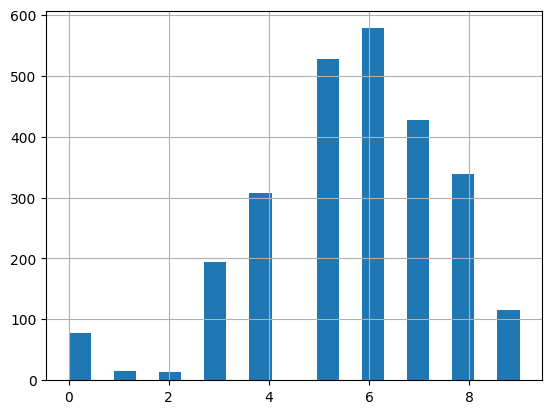

In [36]:
event['event_dvs'].hist(bins=20)

In [37]:
con.sql("""
        SELECT CASE
                WHEN event_dvs = 0 THEN 'NO_Evnets'             
                WHEN event_dvs <= 5 THEN 'LOW'
                WHEN event_dvs <= 6 THEN 'MID-LOW'
                WHEN event_dvs <= 7 THEN 'MID-HIGH'
                ELSE 'HIGH'
               END AS event_dvs_lev
             , ROUND(AVG(retained_01)*100, 2) AS avg_r 
        FROM event_user
        GROUP BY event_dvs_lev
        ORDER BY avg_r DESC
        """).df()

,event_dvs_lev,avg_r
0,HIGH,25.81
1,MID-HIGH,24.70
2,MID-LOW,18.02
3,LOW,16.24
4,NO_Evnets,12.82


In [38]:
#가설3 
con.sql("""
        SELECT event_name
             , COUNT(event_id) cnt
             , ROUND(COUNT(event_id) * 100 / (SELECT COUNT(*) FROM game_log), 4) ratio         
        FROM game_log
        WHERE event_name IN ('purchaseCompleted',
                             'inAppPurchase',
                             'starterPack',
                             'specialPack',
                             'standardPack',
                             'superStarterPack')
        GROUP BY event_name
        """).df()

,event_name,cnt,ratio
0,inAppPurchase,163,0.0032
1,standardPack,3,0.0001
2,purchaseCompleted,161,0.0032
3,starterPack,76,0.0015
4,specialPack,14,0.0003
5,superStarterPack,13,0.0003


In [39]:
#전체 구매 비율
con.sql("""
        SELECT COUNT(*) purchase_cnt,
               ROUND(COUNT(*) * 100 / (SELECT COUNT(*) FROM game_log), 4) AS purchase_ratio
        FROM game_log
        WHERE event_name IN ('purchaseCompleted', 'inAppPurchase', 'starterPack', 'specialPack', 'standardPack', 'superStarterPack')
        """).df()

,purchase_cnt,purchase_ratio
0,430,0.0085


구매 이벤트는 전체 로그 대비 매우 낮은 비율로 나타났으며,단순 구매 여부에 따른 리텐션 비교는 통계적 한계 존재</br>
이에 따라 구매 유저의 초기 행동 패턴을 중심으로 분석 방향 전환

In [40]:
#유저마다 구매 행동이 있었나(0/1), 다음날 돌아왔나(0/1)
 
df = con.sql("""
        WITH first_open AS (
        SELECT user_id
             , MIN(DATE(event_timestamp)) first_dt
        FROM game_log
        WHERE event_name = 'firstOpen'
          AND DATE(event_timestamp) <= '2025-03-04'
        GROUP BY user_id
     ), purchase AS (
        SELECT f.user_id
             , f.first_dt
             , CASE 
               WHEN COUNT(g.event_id) > 0 THEN 1
               ELSE 0
               END purchase_01 
        FROM first_open f
        LEFT JOIN game_log g ON f.user_id = g.user_id 
                            AND f.first_dt = DATE(g.event_timestamp)
                            AND g.event_name IN ('purchaseCompleted', 
                                                 'inAppPurchase', 
                                                 'starterPack',
                                                 'specialPack',
                                                 'standardPack',
                                                 'superStarterPack') 
        GROUP BY f.user_id, f.first_dt
     )
        SELECT p.user_id
             , p.first_dt
             , p.purchase_01
             , CASE 
               WHEN COUNT(g.event_id) > 0 THEN 1
               ELSE 0
               END retained_01
        FROM purchase p 
        LEFT JOIN game_log g ON p.user_id = g.user_id
                            AND DATE(g.event_timestamp) = DATE_ADD(p.first_dt, INTERVAL 1 DAY)
                            AND g.event_name = 'gameOpened'
        GROUP BY p.user_id, p.first_dt, p.purchase_01
        """).df()

df

,user_id,first_dt,purchase_01,retained_01
0,706c32c6-779f-4bad-819d-27563b77df59,2025-03-04,0,1
1,bcbbd9ce-1980-46ca-837b-6746b2adc57d,2025-03-04,0,1
2,59ae4b5d-e46b-44ec-9a43-80868f3c3a4c,2025-03-04,0,1
3,f82c545f-a786-4ede-82c6-3014c3ef2aa0,2025-03-04,0,1
4,f6924e43-3d0f-4be9-9b43-d2397482149d,2025-03-04,0,1
...,...,...,...,...
2850,30a5c371-9c80-4083-881d-cdcb4c73bd2c,2025-03-02,0,0
2851,423a55e3-ed14-4fa9-b8de-d6148fe71d7a,2025-03-02,0,0
2852,c631dedf-5f5e-48c2-a7d7-ab7c6f9be645,2025-03-02,0,0
2853,070198d8-f15c-4ca7-a799-60972c27a8b9,2025-03-02,0,0


In [41]:
con.register('user_act',df)

In [42]:
#구매 유저 vs 비구매 유저 리텐션율
con.sql("""
        SELECT ROUND(AVG(CASE WHEN purchase_01 = 1 THEN retained_01 END) * 100, 2) AS purchase_retention
             , ROUND(AVG(CASE WHEN purchase_01 = 0 THEN retained_01 END) * 100, 2) AS none_retention
        FROM user_act
        """).df()

,purchase_retention,none_retention
0,23.73,21.14


In [43]:
#가입 첫날 구매가 이뤄졌나(0/1)_구매행동패턴

df = con.sql("""
        WITH first_open AS (
        SELECT user_id
             , MIN(DATE(event_timestamp)) first_dt
        FROM game_log
        WHERE event_name = 'firstOpen'
          AND DATE(event_timestamp) <= '2025-03-05'
        GROUP BY user_id
     )
        SELECT f.user_id
             , f.first_dt
             , CASE 
               WHEN COUNT(g.event_id) > 0 THEN 1
               ELSE 0
               END purchase_01 
        FROM first_open f
        LEFT JOIN game_log g ON f.user_id = g.user_id 
                            AND f.first_dt = DATE(g.event_timestamp)
                            AND g.event_name IN ('purchaseCompleted',
                                                 'inAppPurchase', 
                                                 'starterPack', 
                                                 'specialPack', 
                                                 'standardPack', 
                                                 'superStarterPack') 
        GROUP BY f.user_id, f.first_dt
     """).df()

df

,user_id,first_dt,purchase_01
0,ead787b9-73c9-401b-ac4f-baf4cfe3027a,2025-03-05,1
1,ca34b445-bd12-4253-90ac-c9e85de4de1d,2025-03-01,1
2,9fde7ec6-d39e-469b-b548-8be9f393bcb4,2025-03-01,1
3,946b0e13-0d52-4465-90e1-b475b84f1629,2025-03-02,1
4,276bb5f3-8a40-4cf4-9343-3640dd741949,2025-03-02,1
...,...,...,...
3631,95ee6947-5859-49cc-acf4-881f60cf67a2,2025-03-02,0
3632,07d8b343-83e1-4287-8ecd-57438efd4baf,2025-03-02,0
3633,040c246d-755f-4d71-9fc6-ea4a0ca5cff8,2025-03-01,0
3634,e5e1d7d3-6e72-4ca2-95a6-883c2588d8d8,2025-02-28,0


In [44]:
con.register('bm_user', df)

In [45]:
#가입 첫날 구매한 유저의 광고 노출, event 참여 강도 분석
df = con.sql("""
    SELECT bm.user_id
         , bm.first_dt
         , bm.purchase_01
         , COUNT(CASE WHEN g.event_name = 'adsStart' THEN 1 END) AS ad_cnt
         , COUNT(CASE WHEN g.event_name IN (
                    'achievementUpdated',
                    'offerClaim',
                    'deviceUpgrade',
                    'boosterClaimed',
                    'gamerRoadClaimed',
                    'achievementClaimed',
                    'zoneUnlocked',
                    'playerAbilityClaimed',
                    'deviceUnlocked',
                    'currencySpent',
                    'tokenCashout'
               ) THEN 1 END) AS event_proxy_cnt
         , COUNT(DISTINCT CASE WHEN g.event_name IN (
                    'achievement
                    Updated',
                    'offerClaim',
                    'deviceUpgrade',
                    'boosterClaimed',
                    'gamerRoadClaimed',
                    'achievementClaimed',
                    'zoneUnlocked',
                    'playerAbilityClaimed',
                    'deviceUnlocked',
                    'currencySpent',
                    'tokenCashout'
               ) THEN g.event_name END) AS event_dvs
    FROM bm_user bm
    LEFT JOIN game_log g
           ON bm.user_id = g.user_id
          AND bm.first_dt = DATE(g.event_timestamp)
    GROUP BY bm.user_id, bm.first_dt, bm.purchase_01
""").df()

df

,user_id,first_dt,purchase_01,ad_cnt,event_proxy_cnt,event_dvs
0,c104bad7-5f43-4bcf-887e-d0530963b22a,2025-03-05,0,9,134,8
1,02f56434-d123-47c9-9278-bd57e0f730e9,2025-03-05,0,1,47,7
2,5b1b49f7-111f-4e80-9ad3-e2172df0a891,2025-03-05,0,18,259,9
3,2b1a3c35-0dba-4454-b058-f0b91dfefbfb,2025-03-05,0,1,5,4
4,bf66e789-db3b-43c4-8917-82b62182dc70,2025-03-05,0,42,459,7
...,...,...,...,...,...,...
3631,4dbe45ea-f3bd-4adc-b785-e110af417dbc,2025-03-03,0,0,24,4
3632,8bef10c9-a358-448c-9681-e72de37da6b7,2025-03-03,0,0,6,4
3633,520c2503-a4c7-4fc2-a38e-387484e19f5c,2025-03-03,0,1,28,5
3634,0c990ff6-5ff1-4c62-975b-d0ea0daa4b4b,2025-03-01,0,2,34,6


In [46]:
df1 = df[df['purchase_01'] == 1].copy()
df2 = df[df['purchase_01'] == 0].copy()

print(df1.shape)
print(df2.shape)

(72, 6)
(3564, 6)


In [47]:
df1.describe()

,first_dt,purchase_01,ad_cnt,event_proxy_cnt,event_dvs
count,72,72.0,72.000000,72.000000,72.000000
mean,2025-03-02 17:00:00,1.0,15.486111,387.458333,8.819444
min,2025-03-01 00:00:00,1.0,0.000000,40.000000,5.000000
25%,2025-03-01 00:00:00,1.0,2.000000,181.500000,8.000000
50%,2025-03-02 00:00:00,1.0,6.500000,337.000000,9.000000
75%,2025-03-04 00:00:00,1.0,18.000000,552.250000,10.000000
max,2025-03-05 00:00:00,1.0,90.000000,1244.000000,10.000000
std,NaN,0.0,21.017091,275.647404,1.214077


In [48]:
df2.describe()

,first_dt,purchase_01,ad_cnt,event_proxy_cnt,event_dvs
count,3564,3564.0,3564.000000,3564.000000,3564.000000
mean,2025-03-02 21:35:21.212121,0.0,10.048260,102.835578,6.706790
min,2025-02-28 00:00:00,0.0,0.000000,0.000000,0.000000
25%,2025-03-01 00:00:00,0.0,1.000000,23.000000,5.000000
50%,2025-03-03 00:00:00,0.0,4.000000,54.500000,7.000000
75%,2025-03-04 00:00:00,0.0,11.000000,132.000000,8.000000
max,2025-03-05 00:00:00,0.0,227.000000,1477.000000,10.000000
std,NaN,0.0,17.345329,132.537714,2.105857


In [49]:
con.register('purchase_user', df1)

In [50]:
df = con.sql("""
        SELECT p.user_id
             , p.first_dt
             , MIN(CASE WHEN g.event_name = 'firstOpen' THEN CAST(g.event_timestamp AS TIMESTAMP) END) first_visit
             , MIN(CASE WHEN g.event_name IN ('purchaseCompleted', 
                                              'inAppPurchase', 
                                              'starterPack', 
                                              'specialPack', 
                                              'standardPack', 
                                              'superStarterPack') THEN CAST(g.event_timestamp AS TIMESTAMP) END) first_sales 
             , DATEDIFF('minute', first_visit, first_sales) sales_time_min
   
        FROM purchase_user p
        LEFT JOIN game_log g ON p.user_id = g.user_id
                            AND p.first_dt = DATE(g.event_timestamp)
        GROUP BY p.user_id, p.first_dt
        """).df()

df.head()

,user_id,first_dt,first_visit,first_sales,sales_time_min
0,2eb3685b-92a0-428c-8133-25e19b8ea748,2025-03-04,2025-03-04 20:18:01,2025-03-04 21:24:32,66
1,791ea34f-1c7e-4316-983a-9a84a01f7814,2025-03-01,2025-03-01 12:17:12,2025-03-01 12:37:34,20
2,36ea0cd3-a9df-4633-9767-037e93804878,2025-03-01,2025-03-01 13:41:43,2025-03-01 19:31:52,350
3,80582b43-f965-4f14-9847-6106549924e9,2025-03-05,2025-03-05 16:57:05,2025-03-05 22:38:10,341
4,2c194b7a-9828-4d65-927f-4de6c3bfa1f1,2025-03-05,2025-03-05 18:01:56,2025-03-05 18:14:44,13


첫날 구매 유저의 구매 시점은 purchaseCompleted 단일 이벤트가 아니라,</br> 구매 관련 이벤트군 중 최초 발생 시점을 기준으로 산출하였다.
</br> 첫 구매 관련 행동이 나타나기까지 걸린 시간

In [51]:
df['sales_time_min'].describe()

count     72.000000
mean      28.388889
std       60.311295
min        0.000000
25%        2.000000
50%        9.000000
75%       24.500000
max      350.000000
Name: sales_time_min, dtype: float64

<Axes: >

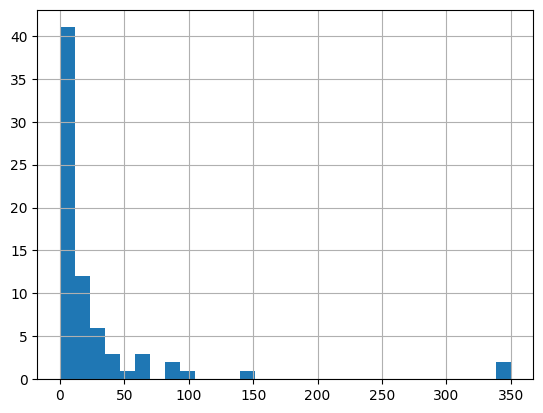

In [52]:
df['sales_time_min'].hist(bins=30)

In [53]:
#유저별 첫구매 관련 이벤트 1건 추출
con.sql("""
        WITH sales AS (
        SELECT p.user_id
             , p.first_dt
             , g.event_name
             , ROW_NUMBER() OVER (PARTITION BY p.user_id, p.first_dt ORDER BY g.event_timestamp) AS sales_rank
        FROM purchase_user p 
        JOIN game_log g ON p.user_id = g.user_id
                        AND p.first_dt = DATE(g.event_timestamp)
        WHERE g.event_name IN ('purchaseCompleted', 
                               'inAppPurchase', 
                               'starterPack', 
                               'specialPack', 
                               'standardPack', 
                               'superStarterPack')
        )
        SELECT *
             , ROUND(event_cnt * 100 / SUM(event_cnt) OVER (), 2) ratio_pct
        FROM (
        SELECT event_name
             , SUM(sales_rank) event_cnt 
        FROM sales
        WHERE sales_rank = 1
        GROUP BY event_name) AS event
        ORDER BY event_cnt DESC
        """).df()

,event_name,event_cnt,ratio_pct
0,purchaseCompleted,26.0,36.11
1,inAppPurchase,22.0,30.56
2,starterPack,16.0,22.22
3,superStarterPack,7.0,9.72
4,standardPack,1.0,1.39


In [54]:
con.sql("""
CREATE OR REPLACE TABLE base_user_engagement AS
    WITH first_open AS (
        SELECT user_id
             , MIN(DATE(event_timestamp)) first_dt
        FROM game_log
        WHERE event_name = 'firstOpen'
          AND DATE(event_timestamp) <= '2025-03-04'
        GROUP BY user_id
     ), retained AS (  
        SELECT f.user_id
             , f.first_dt
             , CASE 
                WHEN COUNT(g.event_id) > 0 THEN 1
                ELSE 0
               END retained_01
        FROM first_open f 
        LEFT JOIN game_log g ON f.user_id = g.user_id
                            AND DATE(g.event_timestamp) = DATE_ADD(f.first_dt, INTERVAL 1 DAY)
                            AND g.event_name = 'gameOpened'
        GROUP BY f.user_id, f.first_dt
     ), event AS (   
        SELECT r.user_id
             , r.first_dt
             , r.retained_01
             , COUNT(g.event_id) event_proxy_cnt
        FROM retained r
        LEFT JOIN game_log g ON r.user_id = g.user_id
                            AND r.first_dt = DATE(g.event_timestamp)
                            AND g.event_name IN ('achievementUpdated',
                                                  'offerClaim',
                                                  'deviceUpgrade',
                                                  'boosterClaimed',
                                                  'gamerRoadClaimed',
                                                  'achievementClaimed',
                                                  'zoneUnlocked',
                                                  'playerAbilityClaimed',
                                                  'deviceUnlocked',
                                                  'currencySpent',
                                                  'tokenCashout')     
        GROUP BY r.user_id, r.first_dt, r.retained_01
     )
SELECT *
FROM event""")

df = con.sql("""
        SELECT *
        FROM base_user_engagement
        """).df()

df

,user_id,first_dt,retained_01,event_proxy_cnt
0,0379be02-76b3-489b-9888-6b8602e8343c,2025-03-01,0,273
1,6c9d90ef-4327-403b-94da-7ffeaa50d5d9,2025-03-01,1,632
2,10639ffa-23b4-48a1-b672-e95de309376f,2025-03-01,0,67
3,30753a63-3d99-4c2d-b750-756aecbfce3c,2025-03-01,1,403
4,6e707d35-b5ef-45e1-a96f-e5a219512808,2025-03-01,0,44
...,...,...,...,...
2850,313c3ace-9a10-4c8f-95c1-a46f0630026d,2025-03-01,1,0
2851,24939347-8694-465b-96f8-0b56516f2a4d,2025-03-02,0,0
2852,bcbbd9ce-1980-46ca-837b-6746b2adc57d,2025-03-04,1,0
2853,b69c6ea9-4303-42e8-b676-6e036d10e7c0,2025-03-04,1,0


In [55]:
#저,중,고몰입 유저 세그먼트(이벤트 수(몰입도proxy) 기준, 균등분할)
con.sql("""
        SELECT sort
             , COUNT(user_id) user_cnt
             , MIN(event_proxy_cnt) min_event
             , MAX(event_proxy_cnt) max_event
             , ROUND(AVG(retained_01) * 100, 2) avg_r
        FROM ( 
             SELECT *
                  , NTILE(3) OVER (ORDER BY event_proxy_cnt) AS sort
             FROM base_user_engagement) AS sort_cnt
        GROUP BY sort
        ORDER BY sort
        """).df()


,sort,user_cnt,min_event,max_event,avg_r
0,1,952,0,32,14.29
1,2,952,32,98,18.17
2,3,951,99,1348,31.13


In [56]:
df['event_proxy_cnt'].describe()

count    2855.000000
mean      106.563222
std       141.384604
min         0.000000
25%        23.000000
50%        55.000000
75%       135.000000
max      1348.000000
Name: event_proxy_cnt, dtype: float64

<Axes: >

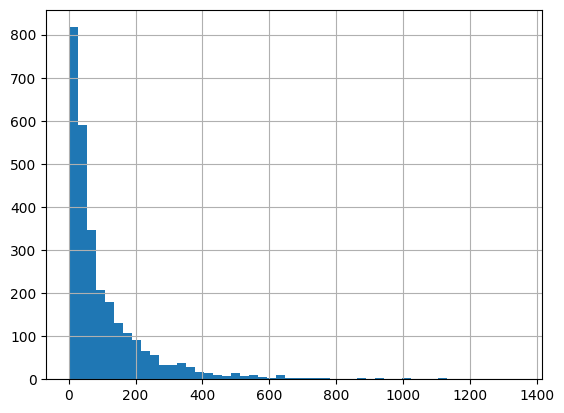

In [57]:
df['event_proxy_cnt'].hist(bins=50)

In [58]:
con.sql("""
        SELECT 몰입도
             , COUNT(user_id) user_cnt
             , MIN(event_proxy_cnt) min_event
             , MAX(event_proxy_cnt) max_event
             , ROUND(AVG(retained_01) * 100, 2) avg_r
        FROM ( 
            SELECT * 
                , CASE 
                    WHEN event_proxy_cnt <= 30 THEN '저몰입'
                    WHEN event_proxy_cnt <= 100 THEN '중몰입'
                    ELSE '고몰입' 
                END AS 몰입도
            FROM base_user_engagement) AS user_focus
        GROUP BY 몰입도
        ORDER BY avg_r
        """).df()

,몰입도,user_cnt,min_event,max_event,avg_r
0,저몰입,916,0,30,14.30
1,중몰입,1004,31,100,18.13
2,고몰입,935,101,1348,31.23
